# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Tech Layoffs 2026 | AI Job Cuts Tracker dataset compiles verified layoff events from 28 major technology companies between January and March 2026, covering roughly 85,000 confirmed job cuts (up to ~101,000 when including planned reductions like Meta's). What sets this dataset apart from typical layoff trackers is its explicit focus on AI attribution — whether a company publicly cited artificial intelligence as a driver of workforce reduction, alongside financial context like revenue, AI capital expenditure, and stock market reaction on the day of announcement.
The dataset is compiled from cross-verified sources (Layoffs.fyi, CNBC, NetworkWorld, TechRepublic, Crunchbase, IBTimes, and others), and includes both quantitative fields (jobs cut, % of workforce, revenue, stock change) and qualitative fields (CEO quotes, roles affected, replacement roles), spanning 10 countries and multiple sectors — enterprise software, e-commerce/cloud, telecom, fintech, semiconductors, and social media/AI.
The dataset frames a specific narrative worth testing rather than assuming: companies cutting tens of thousands of jobs are, in the same period, committing hundreds of billions of dollars to AI infrastructure. Whether this represents direct substitution, coincidental timing, or narrative-driven corporate messaging is exactly the kind of question EDA is suited to interrogate before jumping to conclusions.

# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Data cleaning & structuring — handle missing values, standardize date/percentage/currency fields, verify consistency between jobs_cut, pct_workforce_cut, and pre_layoff_headcount.
<li>Univariate analysis — distribution of layoffs by company, sector, country, month, and layoff-size category.
<li>AI attribution analysis — compare AI-cited vs. non-AI-cited layoffs across size, sector, and stock reaction; check which sectors report the highest AI-cited layoff share.
<li>Market reaction analysis — test whether AI-cited layoffs correlate with more positive stock reactions (the "efficiency signal" hypothesis) versus non-AI-cited cuts.
<li>Financial correlation — examine relationships between company revenue, AI capex (simultaneous_ai_investment_bn), and layoff <li>scale — does higher AI investment coincide with larger cuts, smaller cuts, or no clear pattern?
<li>Time trend — assess whether layoff frequency/size is increasing or decreasing across Jan–Mar 2026.
<li>Sector risk profiling — identify which sectors appear most exposed to AI-driven job cuts based on current data.
</ul>
</div>

## 1. Getting Ready With Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so



In [2]:
data = pl.read_csv('/home/kartika/Datasets/tech_layoffs_2026_tracker.csv')
data = data.to_pandas()
data.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [3]:
data.tail()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
23,Workday,2026-01-28,2200,8.5,Enterprise SaaS,USA,Pleasanton CA,True,AI investment and office space reduction,8.5,...,1750,1750,Computerworld,January 2026,Q1 2026,North America,Large (2K-5K),Positive,8.53,"March 18, 2026"
24,Ergo Insurance,2026-03-01,200,2.0,Insurance,Germany,Dusseldorf,True,AI automates insurance tasks,0.0,...,0,0,Intellizence,March 2026,Q1 2026,Europe,Small (<500),Neutral,2.22,"March 18, 2026"
25,Algoma Steel,2026-03-07,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"
26,Meta Platforms (Planned),2026-03-13,16000,20.0,Social Media/AI,USA,Menlo Park,True,Offset AI infrastructure costs,164.5,...,0,0,CNBC / Reuters / IBTimes,March 2026,Q1 2026,North America,Mega (5K+),Positive,20.25,"March 18, 2026"
27,Algoma Steel,2026-03-23,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure effective,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [5]:
data.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null and duplicate values.

In [7]:
data.drop(columns = ['layoff_date', 'pre_layoff_headcount', 'ceo_quote', 'verified_source', 'data_as_of', 'laid_off_vs_headcount_pct'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped unnecessary and least significant columns.

<div>

## 2 Univariate Analysis

### 2.1Company

In [8]:
data['company'].value_counts()

company
Algoma Steel                2
Block                       1
Amazon                      1
Atlassian                   1
Oracle                      1
Salesforce                  1
Autodesk                    1
eBay                        1
Pinterest                   1
Ericsson                    1
Meta Reality Labs           1
ASML                        1
ams OSRAM                   1
WiseTech Global             1
Ocado                       1
T-Mobile                    1
SK Battery America          1
Walgreens                   1
Cisco                       1
Telefonica                  1
xAI                         1
Livspace                    1
Palo Alto Networks          1
General Motors Tech         1
Workday                     1
Ergo Insurance              1
Meta Platforms (Planned)    1
Name: count, dtype: int64

<div>   

### 2.2Country, Headquarter City and Region

In [9]:
data['country'].value_counts()

country
USA            17
Australia       2
Canada          2
Sweden          1
Austria         1
Netherlands     1
UK              1
Spain           1
India           1
Germany         1
Name: count, dtype: int64

In [10]:
data.groupby('hq_city')['country'].value_counts()

hq_city          country    
Austin           USA            1
Bangalore        India          1
Bellevue         USA            1
Commerce GA      USA            1
Deerfield IL     USA            1
Detroit          USA            1
Dusseldorf       Germany        1
Hatfield         UK             1
Madrid           Spain          1
Menlo Park       USA            2
Pleasanton CA    USA            1
Premstaetten     Austria        1
San Francisco    USA            5
San Jose         USA            2
Santa Clara      USA            1
Sault Ste Marie  Canada         2
Seattle          USA            1
Stockholm        Sweden         1
Sydney           Australia      2
Veldhoven        Netherlands    1
Name: count, dtype: int64

In [11]:
data['region'].value_counts()

region
North America    19
Europe            6
Asia-Pacific      3
Name: count, dtype: int64

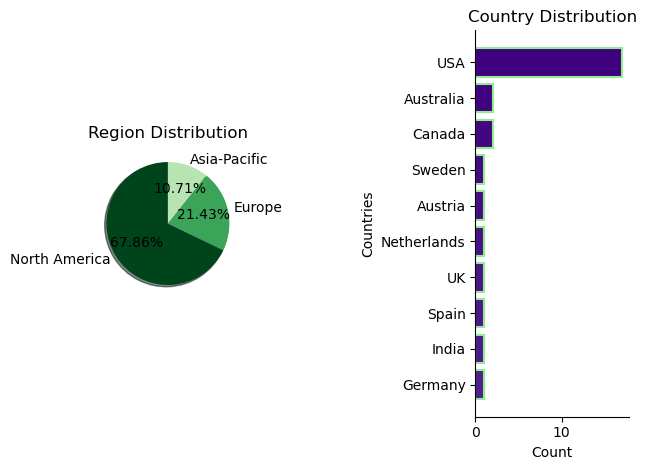

In [12]:
fig, ax = plt.subplots(1, 2)

ax[0].pie(
        data['region'].value_counts().values,
    labels = data['region'].value_counts().index,
    autopct = '%1.2f%%',
    colors = plt.cm.Greens(np.linspace(1, 0.3, 3)),
    startangle = 90,
    shadow = True
)
ax[0].set_title('Region Distribution')


ax[1].barh(
    y = data['country'].value_counts().index,
    width = data['country'].value_counts().values,
    color = plt.cm.Purples(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)
ax[1].set_title('Country Distribution')
ax[1].set_ylabel('Countries')
ax[1].set_xlabel('Count')
ax[1].invert_yaxis()


plt.tight_layout()
sns.despine()
plt.subplots_adjust(wspace = 1.5)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Region wise, most of the companies are from North America, and USA most companies from USA.

<div>

### 2.3 Job Cuts By Number

In [13]:
data['jobs_cut'].describe()

count       28.000000
mean      3612.357143
std       6546.591373
min         50.000000
25%        989.500000
50%       1000.000000
75%       2050.000000
max      30000.000000
Name: jobs_cut, dtype: float64

In [14]:
data['jobs_cut'].skew()

np.float64(3.0976353448502794)

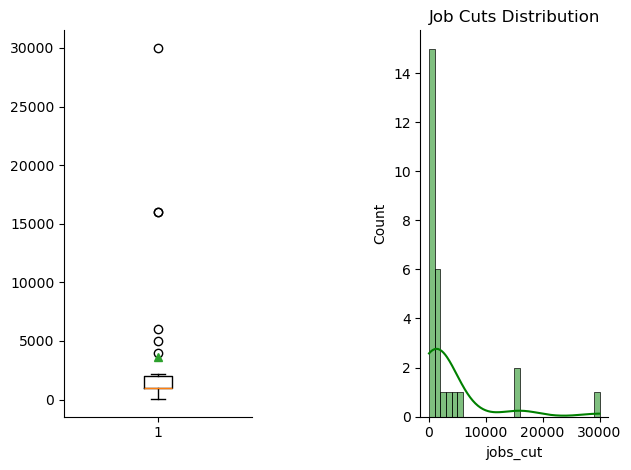

In [15]:

fig, ax = plt.subplots(1,2)

ax[0].boxplot(
    data['jobs_cut'],
    showmeans = True
)


sns.histplot(
    data = data,
    x = data['jobs_cut'],
    bins = 30,
    color = 'green',
    kde = True,
    ax = ax[1]

)

plt.title('Job Cuts Distribution')
plt.tight_layout()
sns.despine()
plt.subplots_adjust(wspace = 0.9)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Jobs cuts distribution is extremely positively skewed, indicating most of the companies have layoff count around 1000, while very few companies have extremely high layoff count >25000.

<div>

In [16]:
data['layoff_size_category'].value_counts()

layoff_size_category
Medium (500-2K)    17
Mega (5K+)          4
Small (<500)        4
Large (2K-5K)       3
Name: count, dtype: int64

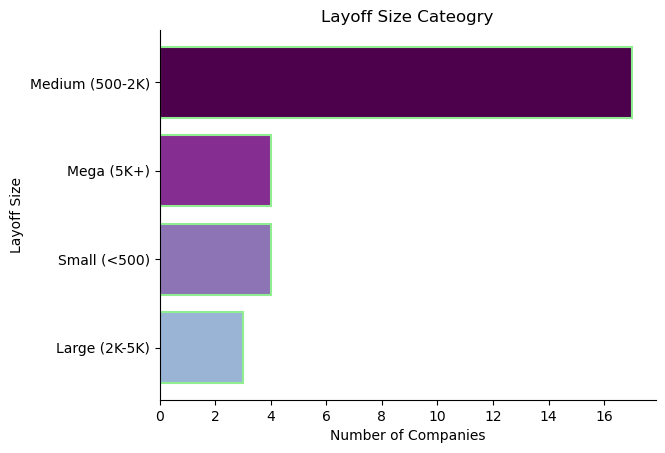

In [17]:
plt.barh(
    y = data['layoff_size_category'].value_counts().index,
    width = data['layoff_size_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.4, 4)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Layoff Size Cateogry')
plt.ylabel('Layoff Size')
plt.xlabel('Number of Companies')
sns.despine()
plt.gca().invert_yaxis()
plt.show()

<div>

In [18]:
data['pct_workforce_cut'].describe()

count    28.000000
mean     10.639286
std      10.433505
min       0.100000
25%       2.525000
50%       7.750000
75%      15.000000
max      40.000000
Name: pct_workforce_cut, dtype: float64

<div>

<div>

### 2.4 Layoffs 2024 vs 2025 vs 2026

In [19]:
data['layoff_increase_2024_2025'] = data['layoffs_2025'] - data['layoffs_2024']

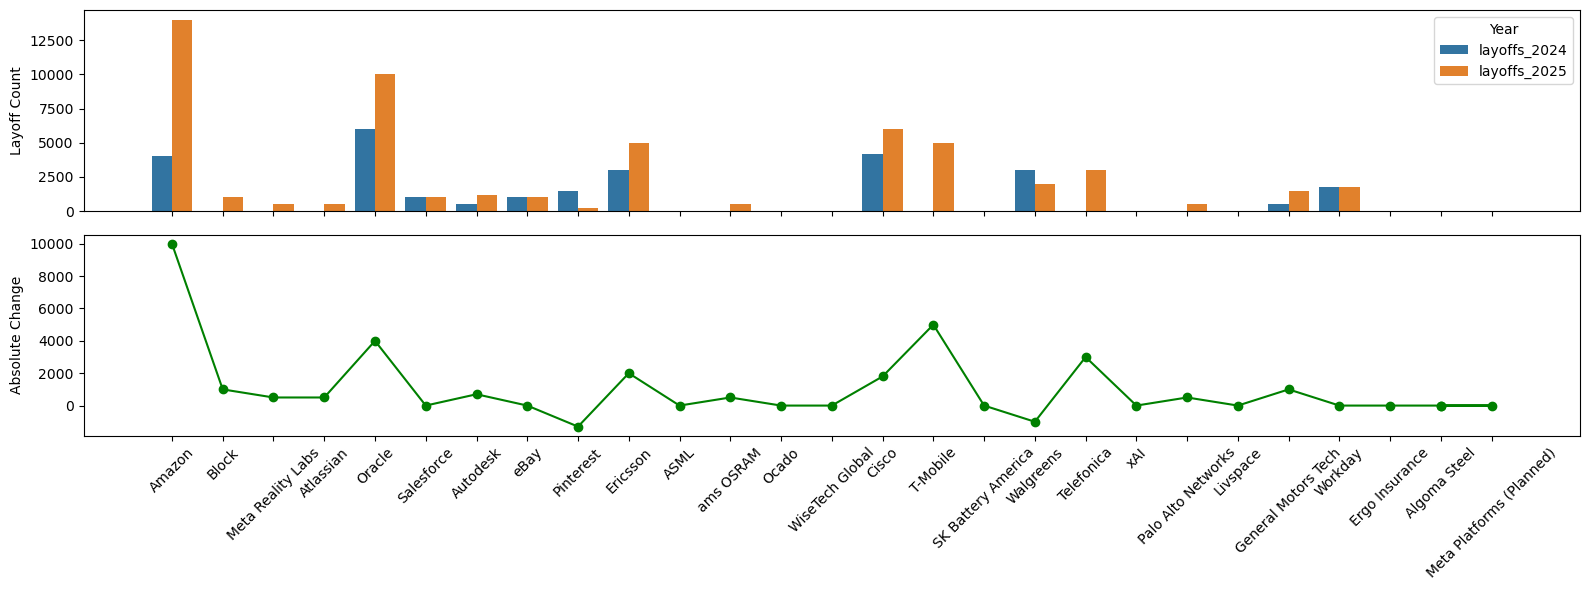

In [20]:
df_long = data.melt(
    id_vars = 'company',
    value_vars = ['layoffs_2024', 'layoffs_2025'],
    var_name = 'Year',
    value_name = 'Layoffs'
)


fig, ax = plt.subplots(2,1, sharex = True, figsize = (16,6))


sns.barplot(
    data = df_long,
    x = 'company',
    y = 'Layoffs',
    hue = 'Year',
    ax = ax[0])
ax[0].set_ylabel('Layoff Count')
ax[0].tick_params(axis = 'x', rotation = 45)



ax[1].plot(
    data['company'],
    data['layoff_increase_2024_2025'],
    marker = 'o',
    color = 'green',
    linewidth = 1.5,
    label = 'Absolute Change'

)
ax[1].set_ylabel('Absolute Change')





plt.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is significant increase in layoffs in 2025 vs 2024 among these companies.

In [21]:
data['layoff_increase_2025_2026'] = data['jobs_cut'] - data['layoffs_2025']

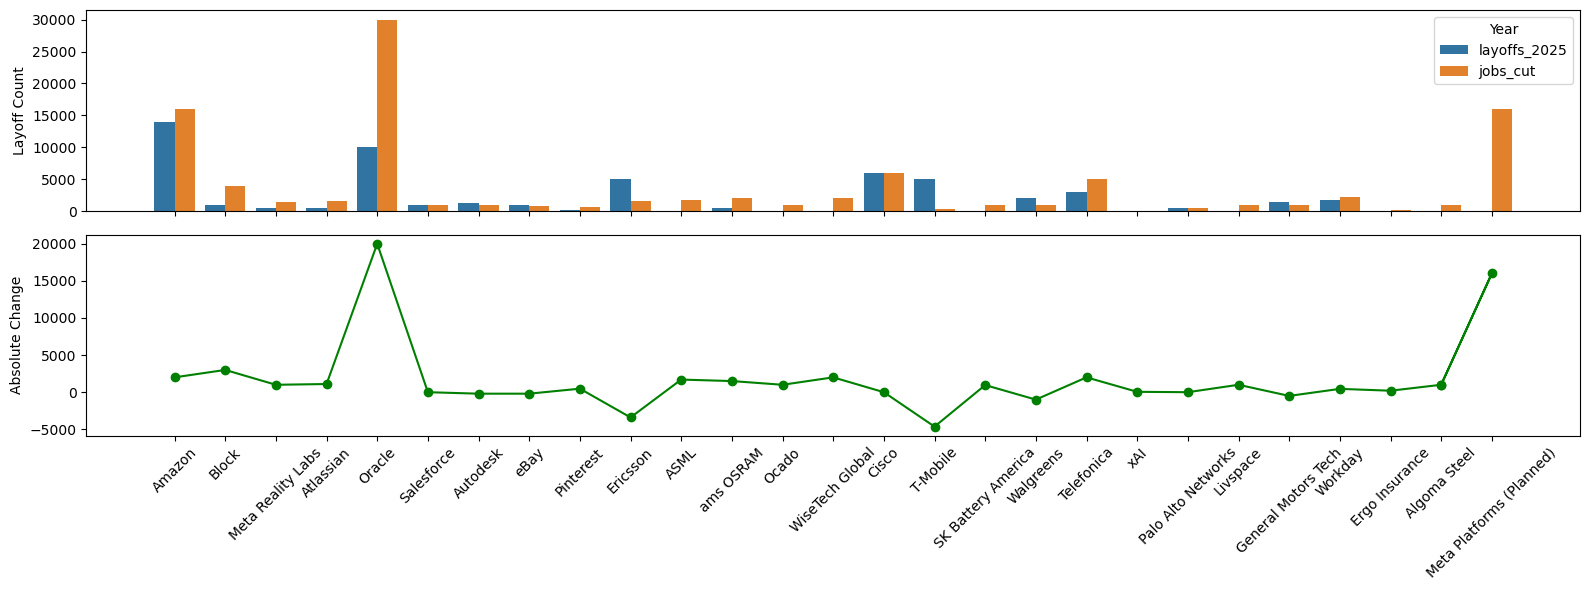

In [22]:
df = data.melt(
    id_vars = 'company',
    value_vars = ['layoffs_2025', 'jobs_cut'],
    var_name = 'Year',
    value_name = 'Layoffs'
)


fig, ax = plt.subplots(2,1, sharex = True, figsize = (16,6))


sns.barplot(
    data = df,
    x = 'company',
    y = 'Layoffs',
    hue = 'Year',
    ax = ax[0])
ax[0].set_ylabel('Layoff Count')
ax[0].tick_params(axis = 'x', rotation = 45)



ax[1].plot(
    data['company'],
    data['layoff_increase_2025_2026'],
    marker = 'o',
    color = 'green',
    linewidth = 1.5,
    label = 'Absolute Change'

)
ax[1].set_ylabel('Absolute Change')





plt.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

<div>

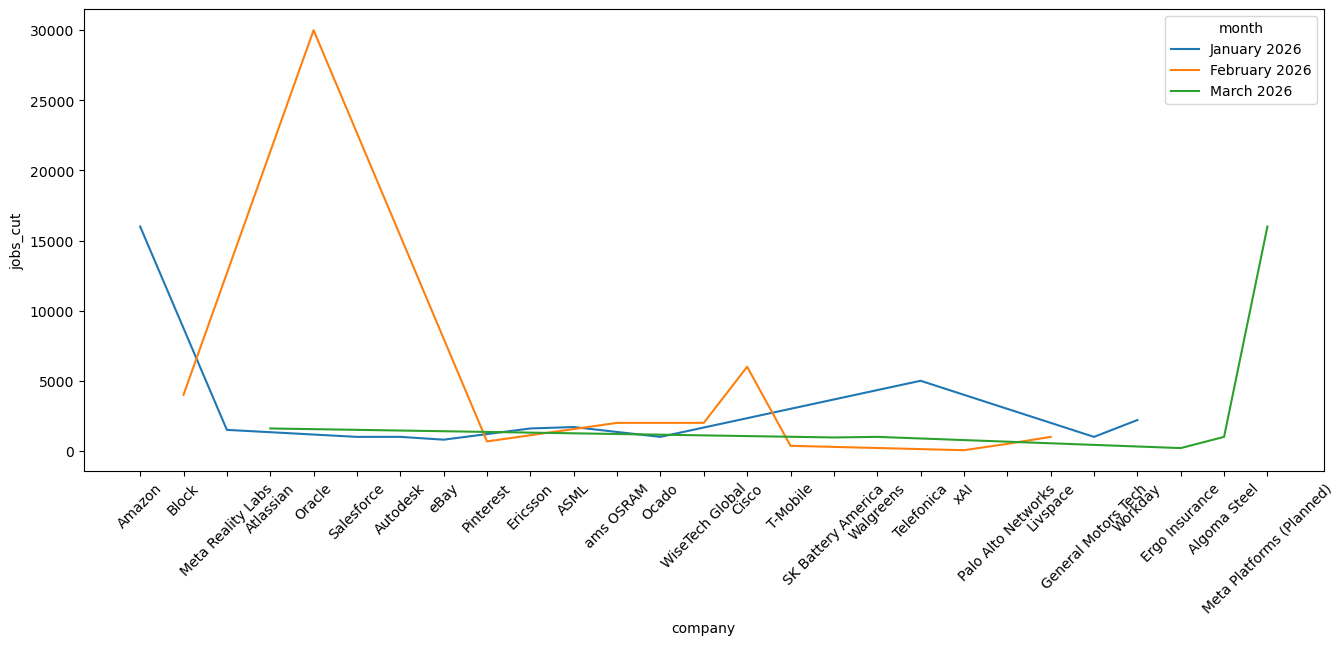

In [23]:
plt.figure(figsize = (16, 6))
sns.lineplot(
    data = data,
    y= 'jobs_cut',
    x = 'company',
    hue = 'month'
)

plt.xticks(rotation = 45)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The year started with big layoff from company like Amazon and Telefonica, other companies had very few layoffs.<br>
In February, Oracle has massive layoff of 30000, followed by WiseTech Global with >7000 job cuts.<br>
In March, only Ergo Insurance had layoff of 15000, other companies show massive decline in layoffs.

<div>

### 2.5 Sectors By Number of Companies

In [24]:
sector_group_map = {
    # Software & Cloud Services
    'Enterprise Software': 'Software & Cloud Services',
    'Enterprise SaaS': 'Software & Cloud Services',
    'CRM/SaaS': 'Software & Cloud Services',
    'Design Software': 'Software & Cloud Services',
    'Logistics Software': 'Software & Cloud Services',
    'E-Commerce/Cloud': 'Software & Cloud Services',

    # Social Media & AI
    'Social Media/AI': 'Social Media & AI',
    'Social Media/VR': 'Social Media & AI',
    'Social Media': 'Social Media & AI',
    'AI Research': 'Social Media & AI',

    # Telecom & Network Infrastructure
    'Telecommunications': 'Telecom & Network Infrastructure',
    'Networking/Cybersecurity': 'Telecom & Network Infrastructure',
    'Cybersecurity': 'Telecom & Network Infrastructure',

    # Hardware & Semiconductors
    'Semiconductors': 'Hardware & Semiconductors',
    'EV Batteries': 'Hardware & Semiconductors',

    # Financial Services
    'Fintech': 'Financial Services',
    'Insurance': 'Financial Services',

    # Retail & Consumer Tech
    'E-Commerce': 'Retail & Consumer Tech',
    'Retail Pharmacy': 'Retail & Consumer Tech',
    'Grocery Tech': 'Retail & Consumer Tech',
    'Interior Design Tech': 'Retail & Consumer Tech',

    # Automotive & Manufacturing
    'Automotive Tech': 'Automotive & Manufacturing',
    'Manufacturing': 'Automotive & Manufacturing',
}

data['sector_group'] = data['sector'].map(sector_group_map)



In [25]:
data['sector_group'].value_counts()

sector_group
Software & Cloud Services           7
Telecom & Network Infrastructure    5
Social Media & AI                   4
Retail & Consumer Tech              4
Hardware & Semiconductors           3
Automotive & Manufacturing          3
Financial Services                  2
Name: count, dtype: int64

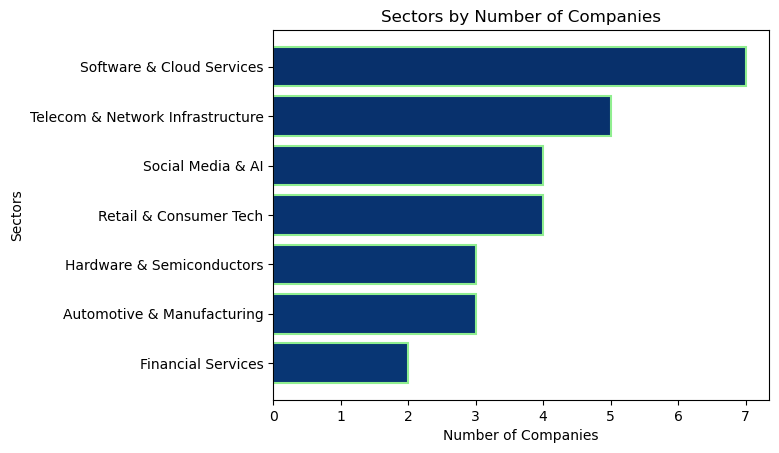

In [26]:
plt.barh(
    y = data['sector_group'].value_counts().index,
    width = data['sector_group'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.9, 23 )),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Sectors by Number of Companies')
plt.ylabel('Sectors')
plt.xlabel('Number of Companies')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The dataset features software & cloud services and telecom & newtwork infrastructure sector companies

<div>

### 2.6 Roles and  Replacements By Number of Companies

In [27]:
data['roles_most_affected'].value_counts()

roles_most_affected
Overlapping roles from merger              2
QA testers, customer support, content      1
Middle management, program managers        1
VR/AR engineers, metaverse designers       1
R&D engineers, QA, IT ops                  1
IT operations, database admins, support    1
Sales support, Tier-1 customer service     1
Content moderation, customer support       1
Content moderation, marketing roles        1
Network engineers, R&D staff               1
Manufacturing support, admin roles         1
Manufacturing, engineering support         1
Warehouse supervisors, logistics           1
QA engineers, manual testers               1
Overlapping roles post-acquisition         1
Sales representatives                      1
Battery production workers                 1
Pharmacy staff, store associates           1
Legacy network operations                  1
Senior engineers, co-founders              1
Interior designers, project managers       1
Software engineers, digital staff  

In [28]:
data['replacement_roles'].value_counts()

replacement_roles
None announced                                  11
AI engineers, data architects                    1
AI prompt engineers, ML engineers                1
AI researchers, LLM engineers                    1
AI infrastructure engineers, GPU specialists     1
AI product managers, enterprise sales            1
Agentforce AI specialists                        1
Cloud integration engineers                      1
AI content reviewers                             1
AI content specialists                           1
Robotics engineers, AI ops                       1
AI test automation engineers                     1
Security AI specialists                          1
Digital roles                                    1
AI design specialists                            1
AI success managers                              1
AI system trainers                               1
AI engineers, GPU infrastructure                 1
Name: count, dtype: int64

In [29]:
category_map = {
    "Overlapping roles from merger": "M&A / Restructuring Overlap",
    "QA testers, customer support, content": "Customer Support & Ops",
    "Middle management, program managers": "Management & Admin",
    "VR/AR engineers, metaverse designers": "Engineering & R&D",
    "R&D engineers, QA, IT ops": "Engineering & R&D",
    "IT operations, database admins, support": "IT Operations & Infrastructure",
    "Sales support, Tier-1 customer service": "Customer Support & Ops",
    "Content moderation, customer support": "Customer Support & Ops",
    "Content moderation, marketing roles": "Sales & Marketing",
    "Network engineers, R&D staff": "Engineering & R&D",
    "Manufacturing support, admin roles": "Manufacturing & Production",
    "Manufacturing, engineering support": "Manufacturing & Production",
    "Warehouse supervisors, logistics": "Warehouse & Logistics",
    "QA engineers, manual testers": "Engineering & R&D",
    "Overlapping roles post-acquisition": "M&A / Restructuring Overlap",
    "Sales representatives": "Sales & Marketing",
    "Battery production workers": "Manufacturing & Production",
    "Pharmacy staff, store associates": "Customer Support & Ops",
    "Legacy network operations": "IT Operations & Infrastructure",
    "Senior engineers, co-founders": "Engineering & R&D",
    "Interior designers, project managers": "Management & Admin",
    "Software engineers, digital staff": "Engineering & R&D",
    "Customer service, admin roles": "Customer Support & Ops",
    "Claims processors, underwriters": "Finance & Insurance Ops",
    "Steel production workers": "Manufacturing & Production",
    "Engineering, middle management, ops": "Cross-Functional (Eng+Mgmt+Ops)",
    "Steel workers": "Manufacturing & Production",
}

data["role_category"] = data['roles_most_affected'].map(category_map)
data["role_category"].value_counts()

role_category
Engineering & R&D                  6
Customer Support & Ops             5
Manufacturing & Production         5
M&A / Restructuring Overlap        3
Management & Admin                 2
IT Operations & Infrastructure     2
Sales & Marketing                  2
Warehouse & Logistics              1
Finance & Insurance Ops            1
Cross-Functional (Eng+Mgmt+Ops)    1
Name: count, dtype: int64

In [30]:
replacement_map = {
    "None announced": "No Replacement Announced",
    "AI engineers, data architects": "AI/ML Core Engineering",
    "AI prompt engineers, ML engineers": "AI/ML Core Engineering",
    "AI researchers, LLM engineers": "AI/ML Core Engineering",
    "AI infrastructure engineers, GPU specialists": "AI Infrastructure & GPU",
    "AI engineers, GPU infrastructure": "AI Infrastructure & GPU",
    "AI product managers, enterprise sales": "AI Product & Go-to-Market",
    "AI success managers": "AI Product & Go-to-Market",
    "Agentforce AI specialists": "AI Applied Specialists",
    "AI content reviewers": "AI Applied Specialists",
    "AI content specialists": "AI Applied Specialists",
    "AI test automation engineers": "AI Applied Specialists",
    "Security AI specialists": "AI Applied Specialists",
    "AI design specialists": "AI Applied Specialists",
    "AI system trainers": "AI Applied Specialists",
    "Robotics engineers, AI ops": "Robotics & Automation",
    "Cloud integration engineers": "Cloud/Traditional Infrastructure",
    "Digital roles": "Unspecified Digital Transformation",
}

data["replacement_category"] = data["replacement_roles"].map(replacement_map)
data["replacement_category"].value_counts()

replacement_category
No Replacement Announced              11
AI Applied Specialists                 7
AI/ML Core Engineering                 3
AI Product & Go-to-Market              2
AI Infrastructure & GPU                2
Cloud/Traditional Infrastructure       1
Robotics & Automation                  1
Unspecified Digital Transformation     1
Name: count, dtype: int64

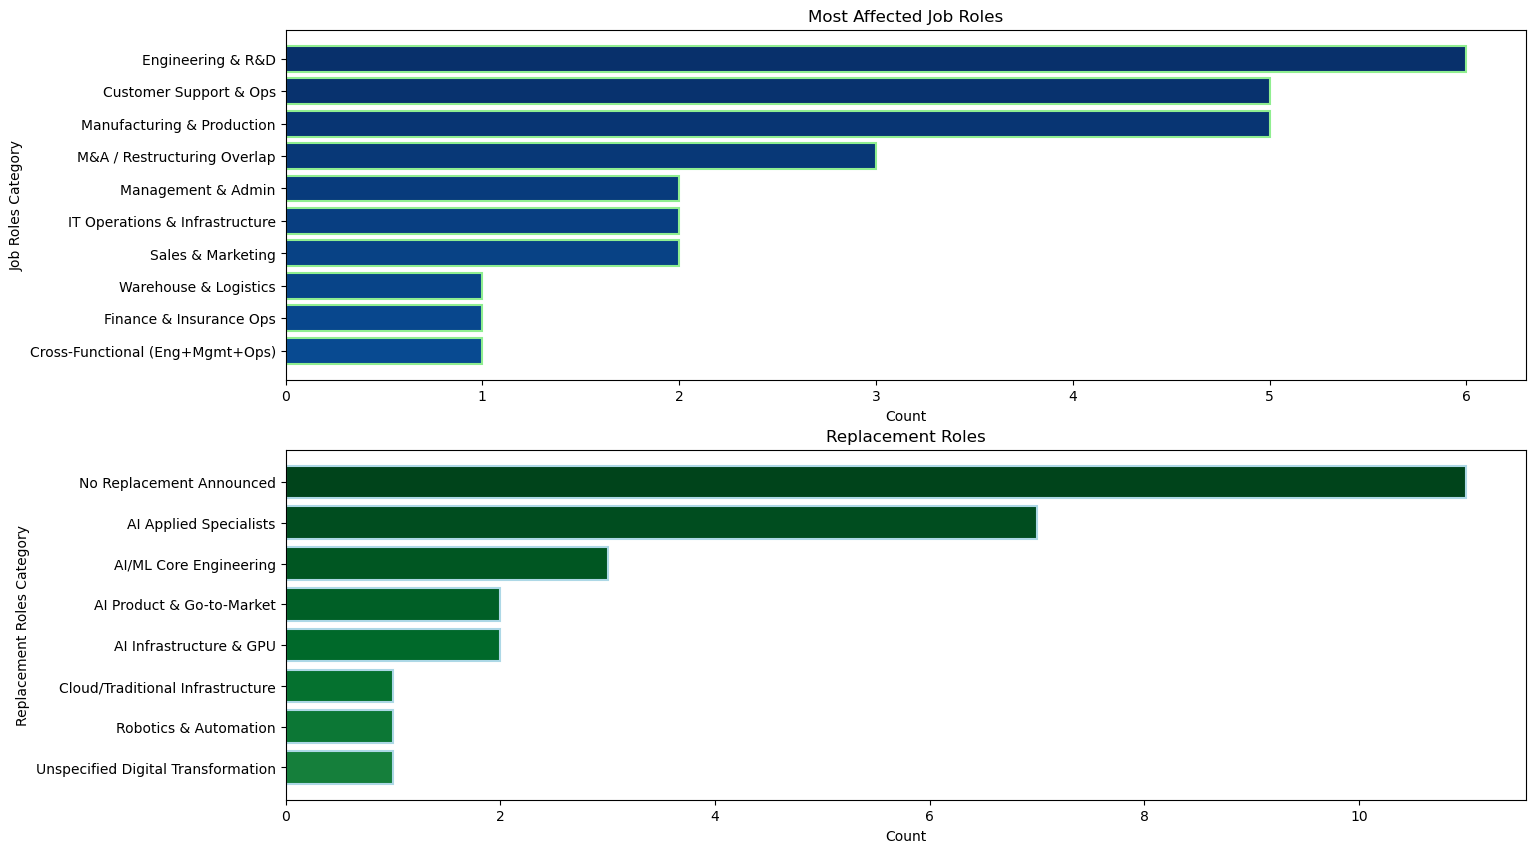

In [31]:

fig, ax = plt.subplots(2, 1, figsize = (16, 10))

ax[0].barh(
    y = data['role_category'].value_counts().index,
    width = data['role_category'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',
)
ax[0].set_title('Most Affected Job Roles')
ax[0].set_ylabel('Job Roles Category')
ax[0].set_xlabel('Count')
ax[0].invert_yaxis()


ax[1].barh(
    y = data['replacement_category'].value_counts().index,
    width = data['replacement_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1, 0.8, 8)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

ax[1].set_title('Replacement Roles')
ax[1].set_ylabel('Replacement Roles Category')
ax[1].set_xlabel('Count')
ax[1].invert_yaxis()


plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Job roles under the categories - Engineering & R&D, Customer Support & Ops, Manufacturing & Production are most affected by layoffs.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Similarly, AI Applied Specialists and AI/ML Core Engineering are most common replacements. Very significant number of replacements are not announced.

<div>

### 2.7 AI Citation

In [32]:
data['ai_cited'].value_counts()
data['ai_cited'] = data['ai_cited'].replace({True : 'Cited', False: 'Not Cited'})

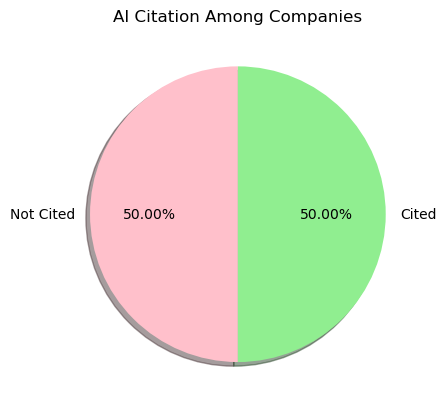

In [33]:
plt.pie(
    data['ai_cited'].value_counts().values,
    labels = data['ai_cited'].value_counts().index,
    colors = ['pink', 'lightgreen'],
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
)

plt.title('AI Citation Among Companies')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Half of the companies in the datase, show AI citation for layoffs, whereas remaining half show no citation of AI.

<div>

### 2.8 Stated Reasons

In [34]:
reason_map = {
    "Reduce bureaucracy and management layers": "Cost Reduction & General Restructuring",
    "AI tools replace roles enabling smaller teams": "AI Replacement of Specific Roles",
    "Pivot from metaverse to AI research": "AI Strategic Pivot & Efficiency",
    "Pivot to AI-first company strategy": "AI Strategic Pivot & Efficiency",
    "AI data centres replace human ops": "AI Replacement of Specific Roles",
    "AI-driven efficiency and restructuring": "AI Strategic Pivot & Efficiency",
    "Post-Ansys acquisition restructuring": "M&A / Acquisition-Driven Restructuring",
    "AI-forward strategy in customer ops": "AI Replacement of Specific Roles",
    "AI-forward content and marketing strategy": "AI Replacement of Specific Roles",
    "Declining 5G demand and cost reduction": "Market/Industry Demand Decline",
    "Chip market slowdown": "Market/Industry Demand Decline",
    "Cost restructuring and portfolio focus": "Cost Reduction & General Restructuring",
    "AI automation in warehouse operations": "AI Replacement of Specific Roles",
    "AI replaces QA and testing teams": "AI Replacement of Specific Roles",
    "Restructuring after Splunk acquisition": "M&A / Acquisition-Driven Restructuring",
    "Restructuring sales teams": "Cost Reduction & General Restructuring",
    "Slowing EV demand": "Market/Industry Demand Decline",
    "Store closures and cost restructuring": "Cost Reduction & General Restructuring",
    "Cost restructuring with compensation": "Cost Reduction & General Restructuring",
    "Internal reorganization": "Cost Reduction & General Restructuring",
    "Post-CyberArk acquisition overlap": "M&A / Acquisition-Driven Restructuring",
    "AI design tools replace human designers": "AI Replacement of Specific Roles",
    "Rethinking digital transformation": "Cost Reduction & General Restructuring",
    "AI investment and office space reduction": "AI Strategic Pivot & Efficiency",
    "AI automates insurance tasks": "AI Replacement of Specific Roles",
    "Blast furnace closure": "Facility / Plant Closure",
    "Offset AI infrastructure costs": "AI Strategic Pivot & Efficiency",
    "Blast furnace closure effective": "Facility / Plant Closure",
}

data["reason_category"] = data["reason_stated"].map(reason_map)
data["reason_category"].value_counts()

reason_category
AI Replacement of Specific Roles          8
Cost Reduction & General Restructuring    7
AI Strategic Pivot & Efficiency           5
M&A / Acquisition-Driven Restructuring    3
Market/Industry Demand Decline            3
Facility / Plant Closure                  2
Name: count, dtype: int64

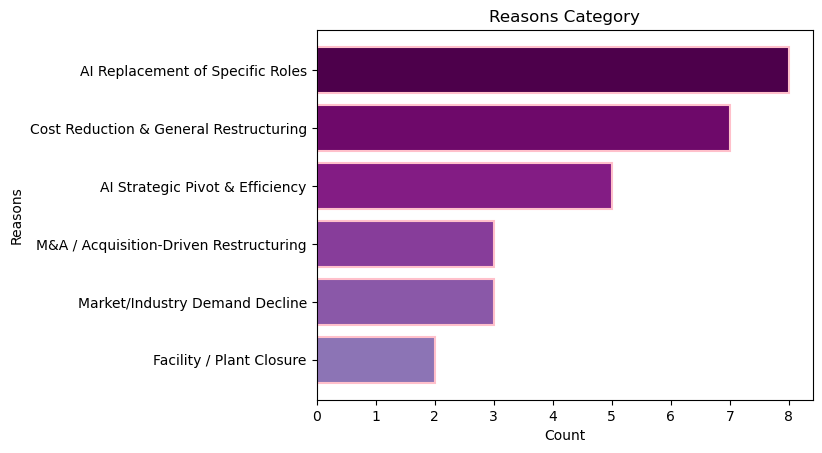

In [35]:
plt.barh(
    y = data['reason_category'].value_counts().index,
    width = data['reason_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'pink'
)

plt.title('Reasons Category')
plt.ylabel('Reasons')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI replacement, AI strategic Pivot and Cost Reduction & General Restructuring are major reasons stated by companies for layoffs.

<div>

### 2.9 Company's Revenue in 2025

In [36]:
data['company_revenue_2025_bn'].describe()

count     28.00000
mean      63.62500
std      139.44986
min        0.00000
25%        3.50000
50%        9.40000
75%       53.90000
max      716.90000
Name: company_revenue_2025_bn, dtype: float64

In [37]:
data['company_revenue_2025_bn'].skew()

np.float64(4.1116111471291985)

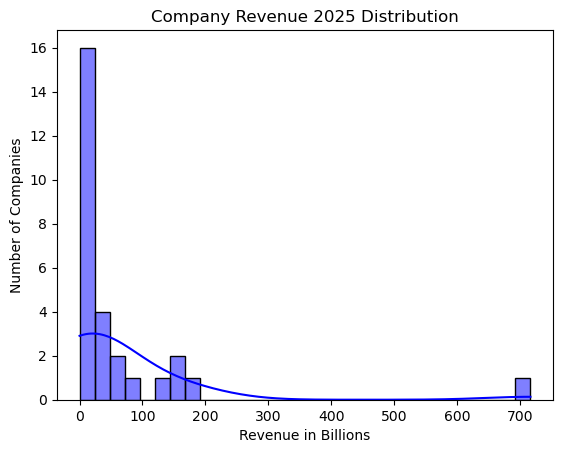

In [38]:
sns.histplot(
    data = data,
    x = 'company_revenue_2025_bn',
    color = 'blue',
    kde = True,
    bins = 30
)

plt.title('Company Revenue 2025 Distribution')
plt.ylabel('Number of Companies')
plt.xlabel('Revenue in Billions')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The revenue distribution of the company in the previous year is extremely positively skewed. 25% of the companies have revenue greater than or equal to 50B, while rest 75% of the companies have revenue less than or equal to 50B.

<div>

### Simultaneous AI Investment

In [39]:
data['simultaneous_ai_investment_bn'].describe()

count     28.000000
mean      14.046429
std       34.751824
min        0.000000
25%        0.000000
50%        0.450000
75%        2.250000
max      115.000000
Name: simultaneous_ai_investment_bn, dtype: float64

In [40]:
data['simultaneous_ai_investment_bn'].skew()

np.float64(2.522709623643781)

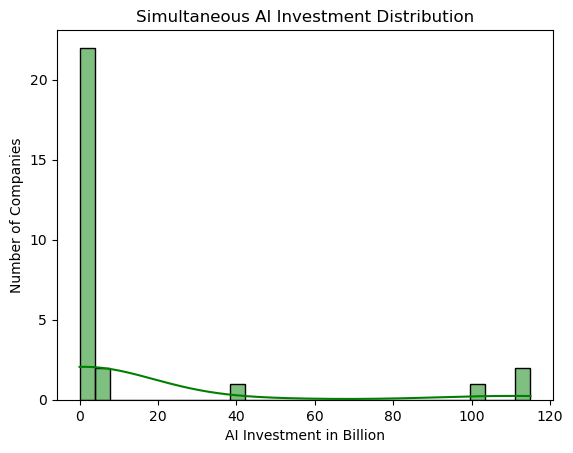

In [41]:
sns.histplot(
    data = data,
    x = 'simultaneous_ai_investment_bn',
    bins = 30,
    color = 'green',
    kde = True,
)

plt.title('Simultaneous AI Investment Distribution')
plt.xlabel('AI Investment in Billion')
plt.ylabel('Number of Companies')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI investment distribution is also heavily positively skewed. Majority of companies have investment less than or equal to 2 billion, while rest have very high investment.

<div>

### 2.11 Stock Change

In [42]:
data['stock_change_day_pct'].describe()

count    28.000000
mean      0.832143
std       1.742721
min      -2.100000
25%      -0.325000
50%       0.650000
75%       1.850000
max       5.800000
Name: stock_change_day_pct, dtype: float64

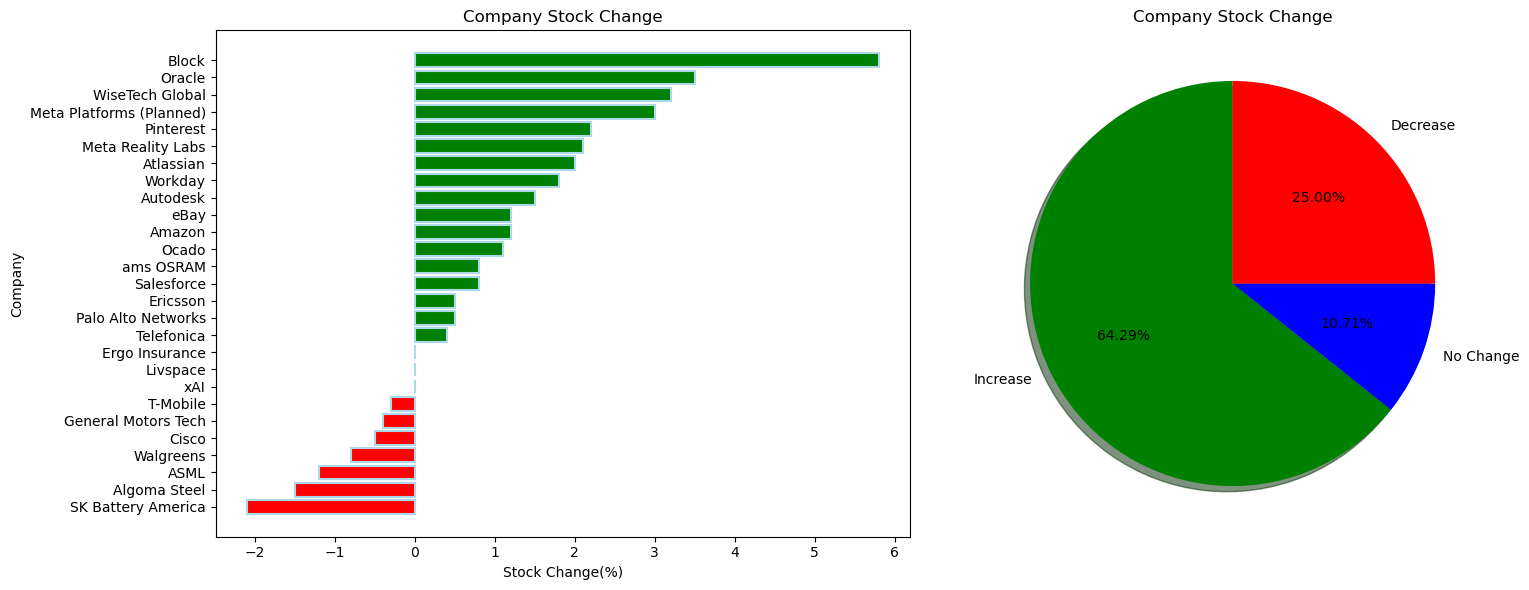

In [43]:

data = data.sort_values('stock_change_day_pct')
colors = ['green' if x >=0 else 'red' for x in data['stock_change_day_pct'] ]

fig, ax = plt.subplots(1, 2, figsize = (16, 6))
ax[0].barh(
    y = data['company'],
    width = data['stock_change_day_pct'].sort_values(),
    color = colors,
    linewidth = 1.5,
    edgecolor = 'lightblue',

)
ax[0].set_title('Company Stock Change')
ax[0].set_ylabel('Company')
ax[0].set_xlabel('Stock Change(%)')


sizes = [18, 3, 7]
labels = ['Increase', 'No Change', 'Decrease']

ax[1].pie(
    sizes,
    labels = labels,
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
    colors = ['green', 'blue', 'red']
)
ax[1].set_title('Company Stock Change')



plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Nearly 65% of the companies observed increase in the stock price, whereas 25% observed decrease in the stock price, while rest 10% had no change in their stock prices.

<div>

<div>

## 3. Bivariate Analysis

### 3.1 Jobs Cut by Sector

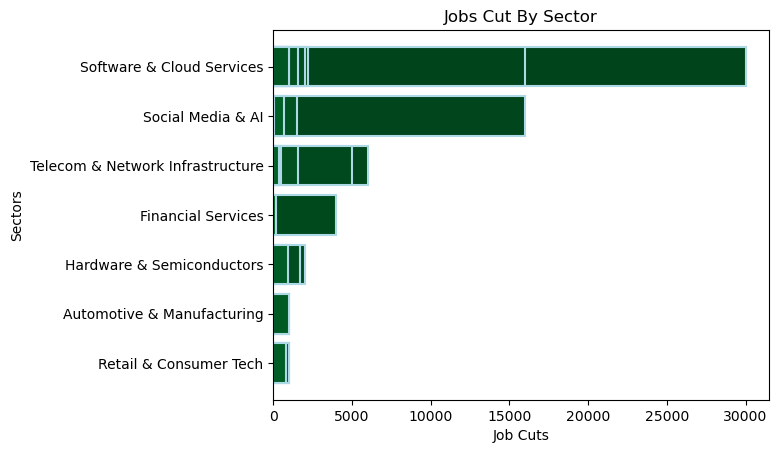

In [44]:

data = data.sort_values('jobs_cut', ascending = False)
plt.barh(
    data['sector_group'],
    data['jobs_cut'],
    color = plt.cm.Greens(np.linspace(1, 0.9, 28)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

plt.title('Jobs Cut By Sector')
plt.ylabel('Sectors')
plt.xlabel('Job Cuts')
plt.gca().invert_yaxis()
plt.show()

###

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Software & Cloud Services, Social Media & AI, Telecom & Network Infrastructure sectors have highest number of layoffs.

<div>

### 3.2 Most Affected Roles by Job Cuts

In [45]:
data.groupby('role_category')['jobs_cut'].sum()

role_category
Cross-Functional (Eng+Mgmt+Ops)    16000
Customer Support & Ops              9000
Engineering & R&D                   7750
Finance & Insurance Ops              200
IT Operations & Infrastructure     35000
M&A / Restructuring Overlap         7500
Management & Admin                 17000
Manufacturing & Production          6658
Sales & Marketing                   1038
Warehouse & Logistics               1000
Name: jobs_cut, dtype: int64

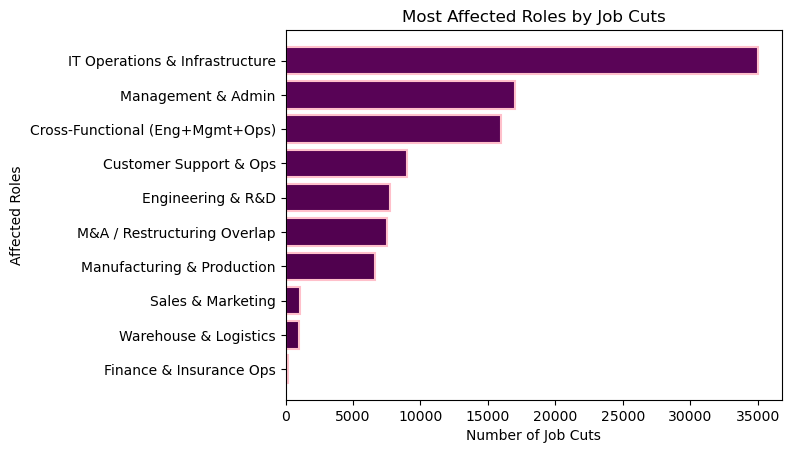

In [46]:
plt.barh(
    y = data.groupby('role_category')['jobs_cut'].sum().sort_values().index,
    width = data.groupby('role_category')['jobs_cut'].sum().sort_values(),
    color = plt.cm.BuPu(np.linspace(1, 0.9, len(data['role_category']))),
    linewidth = 1.5,
    edgecolor = 'pink',

)

plt.title('Most Affected Roles by Job Cuts')
plt.xlabel('Number of Job Cuts')
plt.ylabel('Affected Roles')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">IT Operations & Infrastructure, management & Admin and Cross-Functional (Eng, Mgmt, Ops) are most affected job roles by number of layoffs.

<div>

### 3.3 Sectors and Most Affected Job Roles

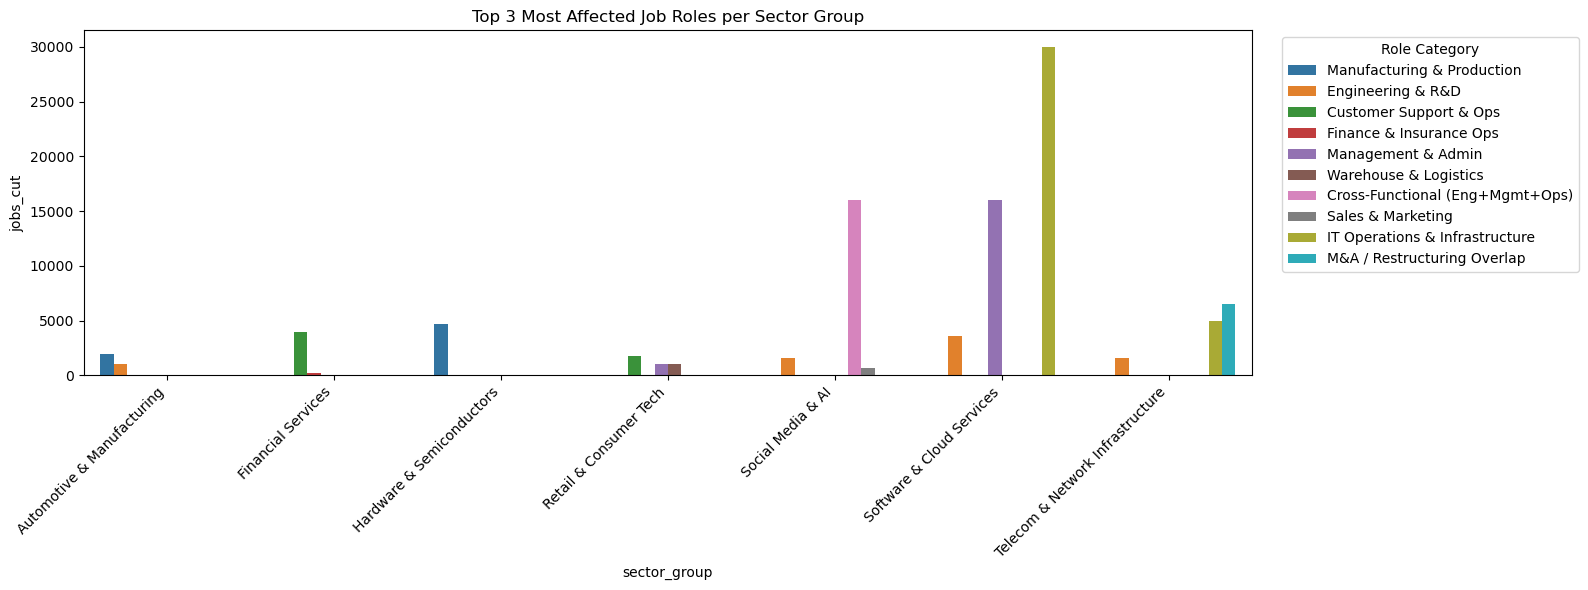

In [47]:
grouped = (
    data.groupby(['sector_group', 'role_category'])['jobs_cut']
    .sum()
    .reset_index()
)

top3 = (
    grouped.sort_values('jobs_cut', ascending=False)
    .groupby('sector_group')
    .head(3)
    .sort_values(['sector_group', 'jobs_cut'], ascending=[True, False])
    .reset_index(drop=True)
)


plt.figure(figsize=(16, 6))
sns.barplot(data=top3, x='sector_group', y='jobs_cut', hue='role_category')
plt.title('Top 3 Most Affected Job Roles per Sector Group')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Role Category')
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The graph shows seven different sector and most affected job roles in that sector.

<div>

### 3.4 Sectors and Most Replaced Job Roles

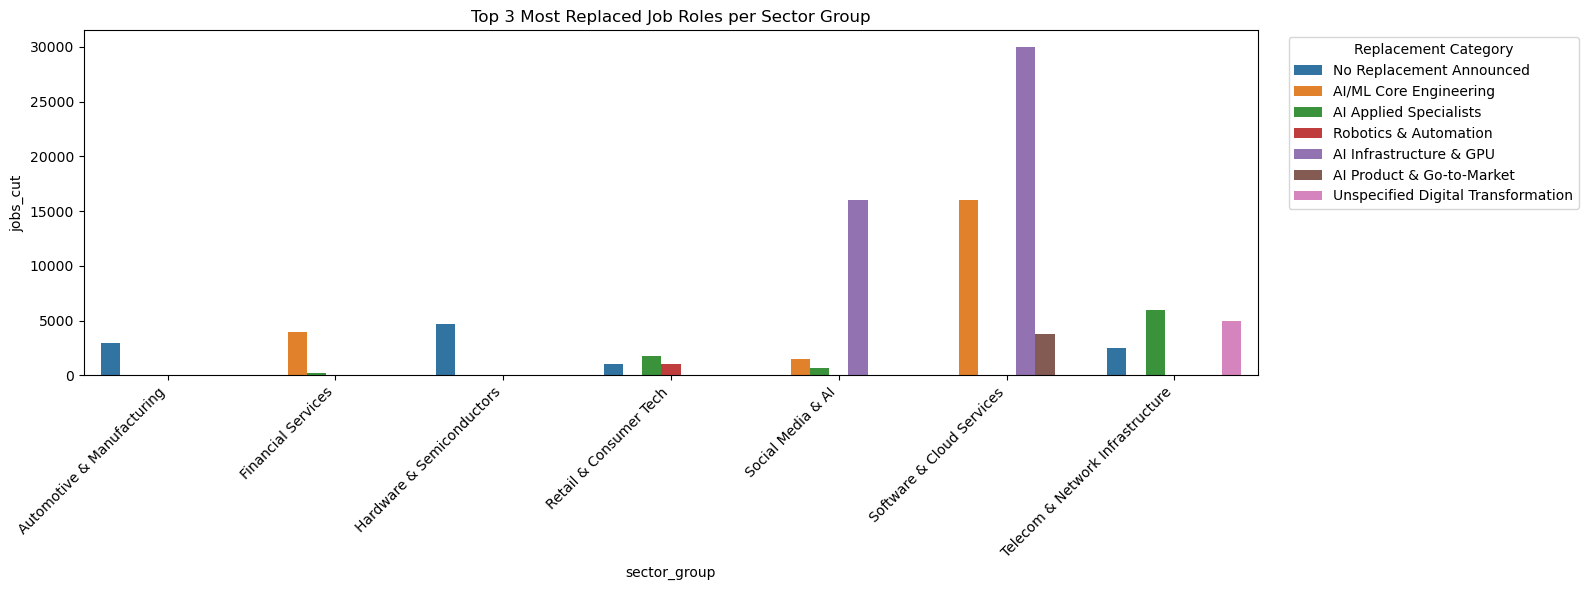

In [48]:
grouped = (
    data.groupby(['sector_group', 'replacement_category'])['jobs_cut']
    .sum()
    .reset_index()
)

top3 = (
    grouped.sort_values('jobs_cut', ascending=False)
    .groupby('sector_group')
    .head(3)
    .sort_values(['sector_group', 'jobs_cut'], ascending=[True, False])
    .reset_index(drop=True)
)


plt.figure(figsize=(16, 6))
sns.barplot(data=top3, x='sector_group', y='jobs_cut', hue='replacement_category')
plt.title('Top 3 Most Replaced Job Roles per Sector Group')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Replacement Category')
plt.tight_layout()
plt.show()




<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The plot shows the most replaced job roles among various sectors.

<div>

### 3.5 Most Affected Roles and Their Replacement

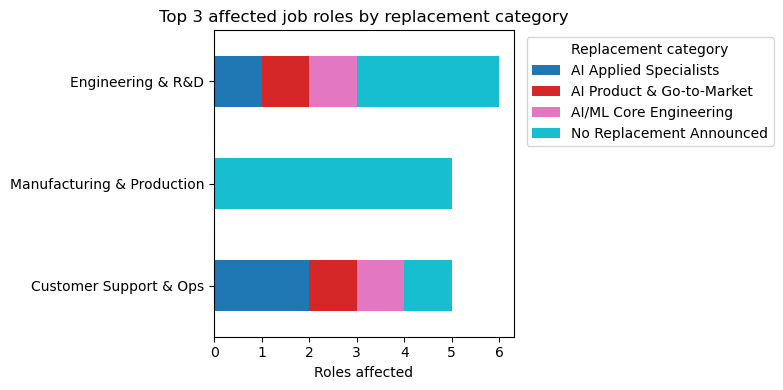

In [49]:


top3 = data['role_category'].value_counts().nlargest(3).index

subset = data[data['role_category'].isin(top3)]
pivot = pd.crosstab(subset['role_category'], subset['replacement_category'])
pivot = pivot.loc[top3]  

pivot.plot(kind='barh', stacked=True, figsize=(8, 4), colormap='tab10')
plt.xlabel('Roles affected')
plt.ylabel('')
plt.title('Top 3 affected job roles by replacement category')
plt.legend(title='Replacement category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> The plot shows the most affected job roles and their corresponding replacements.

<div>

### 3.6 Probable Replacement for (No Replacement Announced)

In [50]:
data.loc[:, ['replacement_category', 'reason_category', 'ai_cited']].head(10)

,replacement_category,reason_category,ai_cited
4,AI Infrastructure & GPU,AI Replacement of Specific Roles,Cited
0,AI/ML Core Engineering,Cost Reduction & General Restructuring,Not Cited
26,AI Infrastructure & GPU,AI Strategic Pivot & Efficiency,Cited
14,AI Applied Specialists,M&A / Acquisition-Driven Restructuring,Not Cited
18,Unspecified Digital Transformation,Cost Reduction & General Restructuring,Not Cited
1,AI/ML Core Engineering,AI Replacement of Specific Roles,Cited
23,AI Product & Go-to-Market,AI Strategic Pivot & Efficiency,Cited
11,No Replacement Announced,Cost Reduction & General Restructuring,Not Cited
13,AI Applied Specialists,AI Replacement of Specific Roles,Cited
10,No Replacement Announced,Market/Industry Demand Decline,Not Cited


In [51]:

mask = data['replacement_category'].str.strip().str.lower() == 'no replacement announced'
not_announced = data.loc[mask, ['role_category', 'replacement_category', 'reason_category', 'ai_cited']]

not_announced

,role_category,replacement_category,reason_category,ai_cited
11,Manufacturing & Production,No Replacement Announced,Cost Reduction & General Restructuring,Not Cited
10,Manufacturing & Production,No Replacement Announced,Market/Industry Demand Decline,Not Cited
9,Engineering & R&D,No Replacement Announced,Market/Industry Demand Decline,Not Cited
25,Manufacturing & Production,No Replacement Announced,Facility / Plant Closure,Not Cited
17,Customer Support & Ops,No Replacement Announced,Cost Reduction & General Restructuring,Not Cited
22,Engineering & R&D,No Replacement Announced,Cost Reduction & General Restructuring,Not Cited
27,Manufacturing & Production,No Replacement Announced,Facility / Plant Closure,Not Cited
16,Manufacturing & Production,No Replacement Announced,Market/Industry Demand Decline,Not Cited
20,M&A / Restructuring Overlap,No Replacement Announced,M&A / Acquisition-Driven Restructuring,Not Cited
15,Sales & Marketing,No Replacement Announced,Cost Reduction & General Restructuring,Not Cited


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">For the companies, those who didn't announced replacement, mainly stated cost reduction, general restructuring and market/industry demand decline as major reasons. Also, most of the companies have no AI citation as major reason.

<div>


### 3.7 Job Cuts and AI Citation

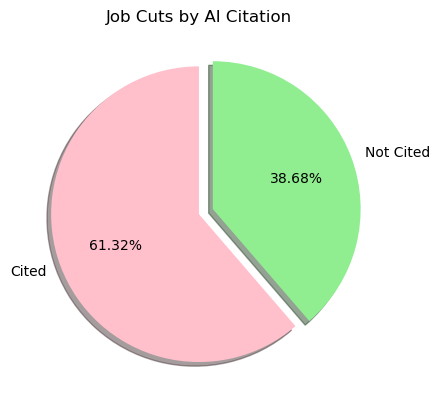

In [52]:

sums = data.groupby('ai_cited')['jobs_cut'].sum()

plt.pie(
    sums.values,
    labels = sums.index,
    autopct = '%1.2f%%',
    colors = ['pink', 'lightgreen'],
    startangle = 90,
    shadow = True,
    explode = [0, 0.1]

)

plt.title('Job Cuts by AI Citation')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">61% of the layoffs cited AI as reason for job cuts.

<div>

### 3.8 Affected Roles and AI Citation

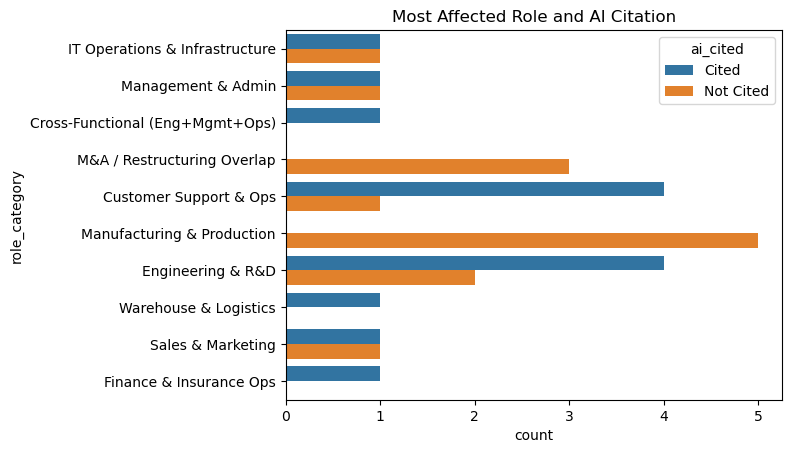

In [53]:
sns.countplot(
    data = data,
    y = 'role_category',
    hue = 'ai_cited',

)

plt.title(
    'Most Affected Role and AI Citation'
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI is mainly cited in job roles such as customer support & Ops, Engineering and R&D.


<div>

### 3.9 Sector and AI Citation

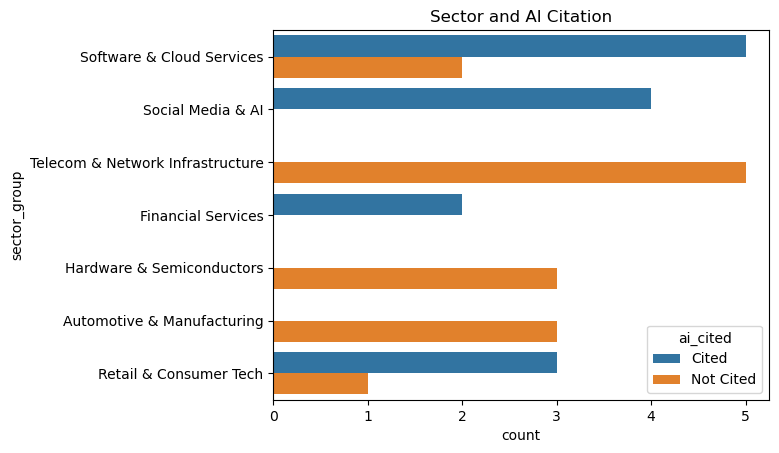

In [54]:
sns.countplot(
    data = data,
    y = 'sector_group',
    hue = 'ai_cited',

)

plt.title(
    'Sector and AI Citation'
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI is mainly cited in sectors such as Software & Cloud Services, Social Media & AI, Retail & Consumer Tech.

 <div>

### 3.10 Previous Year Revenue(2025) vs Layoffs

In [55]:
data['company_revenue_2025_bn'].corr(data['jobs_cut'])

np.float64(0.4345185528860951)

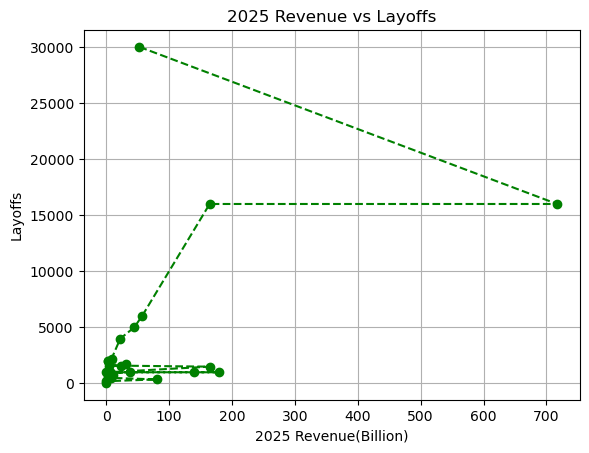

In [56]:
plt.plot(
    data['company_revenue_2025_bn'],
    data['jobs_cut'],
    marker = 'o',
    linewidth = 1.5,
    linestyle = '--',
    color = 'green',
)

plt.title('2025 Revenue vs Layoffs')
plt.xlabel('2025 Revenue(Billion)')
plt.ylabel('Layoffs')
plt.grid(True)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">A correlation of 0.43 indicates a moderate, positive linear relationship between previous year revenue and layoffs. As the previous years's revenue increases, layoffs tends to increase as well, but the association is not strong and does not imply that higher revenue causes layoffs. The correlation is affected by small number of companies with exceptionally high revenue and large layoffs.


<div>

### 3.11 Simultaneous AI Investment vs Job Cuts

In [59]:
data['simultaneous_ai_investment_bn'].corr(data['jobs_cut'])

np.float64(0.5579307642382292)

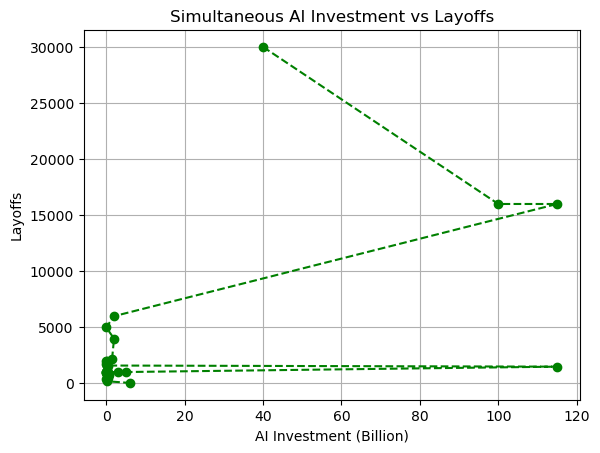

In [57]:
plt.plot(
    data['simultaneous_ai_investment_bn'],
    data['jobs_cut'],
    marker = 'o',
    linewidth = 1.5,
    linestyle = '--',
    color = 'green',
)

plt.title('Simultaneous AI Investment vs Layoffs')
plt.xlabel('AI Investment (Billion)')
plt.ylabel('Layoffs')
plt.grid(True)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">A correlation of 0.55 indicates a moderate, positive linear relationship between simultaneous AI investment and layoffs. As the  simultaneous AI investment increases,layoffs tends to increase as well, but the association is not strong and does not imply that simultaneous causes layoffs. The correlation is affected by small number of companies with exceptionally high AI investment and large layoffs.

<div>

### 3.12 Sectors vs Simultaneous AI Investment

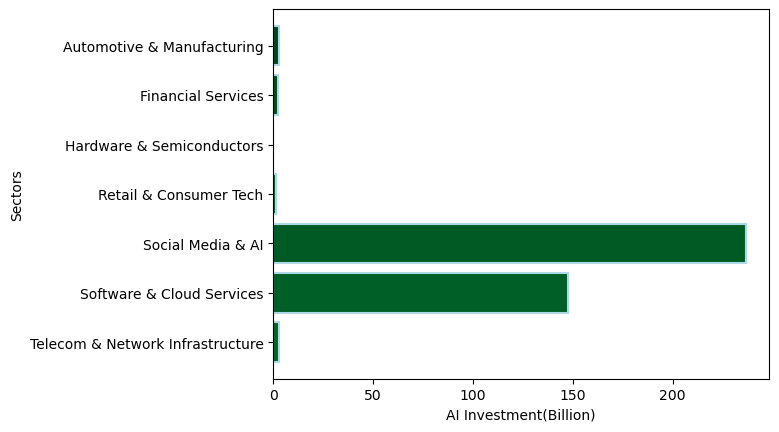

In [63]:
group = data.groupby('sector_group')['simultaneous_ai_investment_bn'].sum()

plt.barh(
    y = group.index,
    width = group.values,
    color = plt.cm.Greens(np.linspace(1, 0.9, len(group))),
    linewidth = 1.5,
    edgecolor = 'lightblue',


)

plt.ylabel('Sectors')
plt.xlabel('AI Investment(Billion)')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Among seven different sectors presented in this dataset, Social Media & AI and Software & Cloud Services have the highest Investment in AI.

<div>

### 3.13 AI Citation vs Stock Price


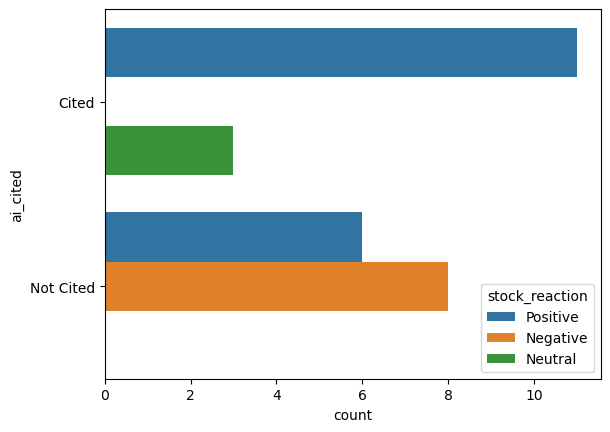

In [67]:
sns.countplot(
    data = data,
    y = 'ai_cited',
    hue = 'stock_reaction'
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Companies that cited AI, observed increase in their stock price.

<div>

### 3.14 Simultaneous AI Investment vs Stock Price Change

In [71]:
data['simultaneous_ai_investment_bn'].corr(data['stock_change_day_pct'])

np.float64(0.3305224113026243)

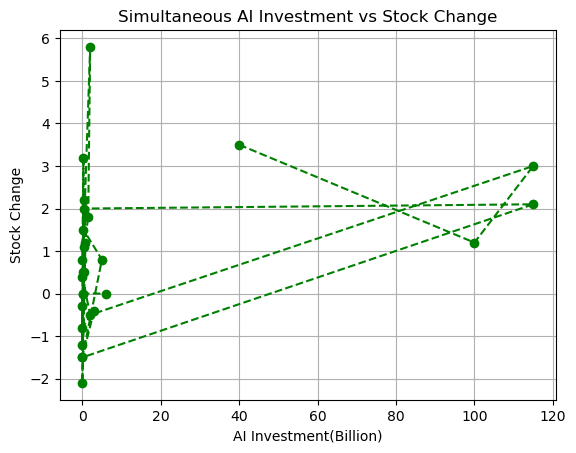

In [72]:
plt.plot(
    data['simultaneous_ai_investment_bn'],
    data['stock_change_day_pct'],
    marker = 'o',
    linewidth = 1.5,
    linestyle = '--',
    color = 'green',
)

plt.title('Simultaneous AI Investment vs Stock Change')
plt.xlabel('AI Investment(Billion)')
plt.ylabel('Stock Change')
plt.grid(True)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is a low-moderate linear correlation between simultaneous AI investment and stock price change. The relationship has noticeable trend, but there is significant scatter of variance in the data.

<div>

# Major Findings

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Most companies are USA based, USA is most affected by major layoffs in first quarter of 2026.
<li>Most companies have medium job cuts, while few big companies have extremely large job cuts.
<li>There is a significant rise in layoffs from in 2025 in comparions to 2024. Similar trend follows in 2026, but mainly in top companies like Amazon, Oracle, other companies showed either same or decline in job cuts.
<li>The first quarter of 2026 started with some major tech layoffs, 16000 layoffs from Amazon in Jan, 30000 from Oracle and 6000 from Cisco in Feb and 16000 from Meta in March.
</ul>


</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>By number of job cuts, most affected sectors are Software & Cloud Service, Social Media & AI and Telecom & Network Infrastructure. Out of these three most affected sectors, Software & Cloud Service heavily cited AI and Social Media & AI moderately cited AI. There was no AI citation in Telecom and Network Infrastructure sector.
<li>Additionally, out of these top three sectors, Social Media & AI has the highest simultaneous AI investment.



</ul>

</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Most affected job roles in most affected sector:
<ul>
<li>Software & Cloud Service --> Management & Admin
<li>Social Media & AI --> Cross Function (Mgmt + Eng + Ops)
<li>Telecom & Network Infrastructure --> Engineering & R&D
</ul>
<li>Replacements of most affected job roles:
<ul>
<li>Management & Admin --> AI Infrastructure and GPU
<li>Cross Function (Mgmt + Eng + Ops) --> AI Infrastructure and GPU
<li>Engineering & R&D --> AI Applied Specialist 

</ul>
</ul>
</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Most commonly stated reasons for layoffs by companies are:
<ul>
<li>AI replacement of specific role
<li>Cost reduction and general restructuring
<li>AI strategic Pivot & Efficiency
</ul>

</ul>

</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>61% of the job cuts cited AI.
<li>65% of the companies observed positive stock change, 25% observed negative stock change, while rest remained neutral.
<li>Those companies who cited AI, eithe observed positive or neutral stock change.
<li>Those companies whoe didn't cite AI, observed both negative or positive stock change.
<li>There is a moderate positive linear relationship between simultaneous AI investment and layoffs. But, the association is not strong and doesn't imply that AI investment causes layoffs. The correlation is heavily affected by small number of companies with exceptionally high AI investment and large layoffs.
</ul>

</div>